In [9]:
from pathlib import Path
import pandas as pd 
import numpy as np
from tqdm.auto import tqdm
import plotly.express as px
from plotly import graph_objects as go
tqdm.pandas()
from results_utils import load_bootstrap_metrics, get_traits


root = Path('/marbec-data/RLS-Australia/malpolon/xgb/')
inputs_path = Path('/marbec-data/RLS-Australia/malpolon/inputs/australia/')
output_path = Path('/marbec-data/RLS-Australia/malpolon/outputs/')

In [10]:
fulldf = pd.read_csv(inputs_path / 'database_common.csv', index_col='survey_id',
                     dtype = {22:str, 24:str, 25:str})
species = list(fulldf.columns[-818:-1])
groundtruth = fulldf[species]

In [11]:
# Checkpoints

ind_cp_pa = '42_ind_pa_seedtest-2026-03-12_17-19'
td_cp_pa = '42_td_pa_seedtest-2026-03-11_14-31'

ind_cp_reg = '42_ind_reg_seedtest-2026-03-13_00-38'
td_cp_reg = '42_td_reg_seedtest-2026-03-12_10-21'

ind_cp_eco = '42_ind_eco_seedtest-2026-03-10_17-43'
td_cp_eco = '42_td_eco_seedtest-2026-03-10_14-13'

## P-A

#### Species F1

In [14]:
import matplotlib.pyplot as plt
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.express as px
import math

metrics = ['Boyce', 'F1', 'AUC', 'maxTSS', ]  # add more metrics here
metric_name = ['CBI', 'F1', 'AUC-ROC', 'maxTSS', ]  # add more metrics here

names = ['XGBoost', 'Deep-SDM', 'Transductive']
colors = px.colors.qualitative.Pastel

In [ ]:
for idx, metric in enumerate(metrics):
    
    fig = go.Figure()

    # --- compute values (unchanged) ---
    xgb_mean, xgb_ci = load_bootstrap_metrics(output_path.parent / 'xgb', 'pa', pa_metric=metric)
    ind_mean, ind_ci = load_bootstrap_metrics(output_path, ind_cp_pa, pa_metric=metric)
    td_mean, td_ci = load_bootstrap_metrics(output_path, td_cp_pa, pa_metric=metric)

    scores = [xgb_mean, ind_mean, td_mean]
    errors = [xgb_ci, ind_ci, td_ci]

    # --- plotting ---
    for i, n in enumerate(names):

        if errors[i] is not None:
            fig.add_trace(go.Scatter(
                x=np.concatenate([np.arange(400), np.arange(400)[::-1]]),
                y=np.concatenate([scores[i] + errors[i], (scores[i] - errors[i])[::-1]]),
                fill='toself',
                fillcolor=colors[i % len(colors)].replace('rgb(', 'rgba(').replace(')', ', 0.4)'),
                line=dict(color='rgba(255,255,255,0)'),
                name='95% CI'
            ))

        fig.add_trace(go.Scatter(
            x=np.arange(400),
            y=np.array(scores[i]),
            mode='lines',
            line=dict(color=colors[i % len(colors)], width=3),
            name=n
        ))

    # --- layout ---
    fig.update_layout(
        template='simple_white',
        width = 800,
        height = 600,
        title={'text': metric_name[idx],
                'xanchor': 'center',
                'x': 0.5},
        xaxis_title='',
        yaxis_title='',
        font=dict(size=20),
        legend_title_text='',
        legend=dict(
            yanchor="bottom" if idx >=2 else "top",
            y=0 if idx >=2 else 0.99,
            xanchor="left" if idx >=2 else "right",
            x=0 if idx >=2 else 0.99
        )
    )

    fig.show()

In [ ]:
import seaborn as sns
from matplotlib import pyplot as plt

x, y = scores[names[0]].values, scores[names[2]].values

# Draw a combo histogram and scatterplot with density contours
f, ax = plt.subplots(figsize=(9, 9))
sns.scatterplot(x=x, y=y, s=5, color=".15")
sns.histplot(x=x, y=y, bins=40, pthresh=.1, cmap="mako")
sns.kdeplot(x=x, y=y, levels=5, color="w", linewidths=1)
sns.lineplot(x=[min(x), max(x)], y=[min(x), max(x)],color='red')
ax.set(xlabel=names[0] + ' F1', ylabel=names[2] + ' F1')

#### Sankey

In [4]:
# P-A

metric = 'Boyce'

xgb_mean, xgb_ci = load_bootstrap_metrics(output_path.parent / 'xgb', 'pa', pa_metric=metric, reindex = False)
ind_mean, ind_ci = load_bootstrap_metrics(output_path, ind_cp_pa, pa_metric=metric, reindex = False)
td_mean, td_ci = load_bootstrap_metrics(output_path, td_cp_pa, pa_metric=metric, reindex = False)

scores = pd.concat([xgb_mean, ind_mean, td_mean], axis = 1)
names = ['XGB', 'Inductive', 'Transductive']
#categories = ['Exceptional (AUC>0.98)', 'Good (AUC>0.95)', 'Acceptable (AUC>0.9)', 'Slight (AUC>0.8)', 'Bad (AUC<0.8)']
categories = ['Exceptional (CBI>0.75)', 'Good (CBI>0.5)', 'Acceptable (CBI>0.25)', 'Slight (CBI>0)', 'Bad (CBI<0)']
scores.columns = names

qualscores = pd.DataFrame(index=scores.index)
for n in  names:
    #qualscores[n] = pd.cut(scores[n], bins=[0, 0.8, 0.9, 0.95, 0.98, 1.0], labels=categories[::-1])
    qualscores[n] = pd.cut(scores[n], bins=[-1, 0, 0.25, 0.5, 0.75, 1.0], labels=categories[::-1])

#qualscores.fillna('Bad (AUC<0.8)', inplace=True)
qualscores.fillna('Bad (CBI<0)', inplace=True)
qualscores = pd.concat([qualscores, get_traits(qualscores.index, traits_path = inputs_path)], axis=1)

species_prev = (groundtruth > 0).sum(axis=0) / groundtruth.shape[0]
qualscores['prevalence'] = species_prev[qualscores.index]

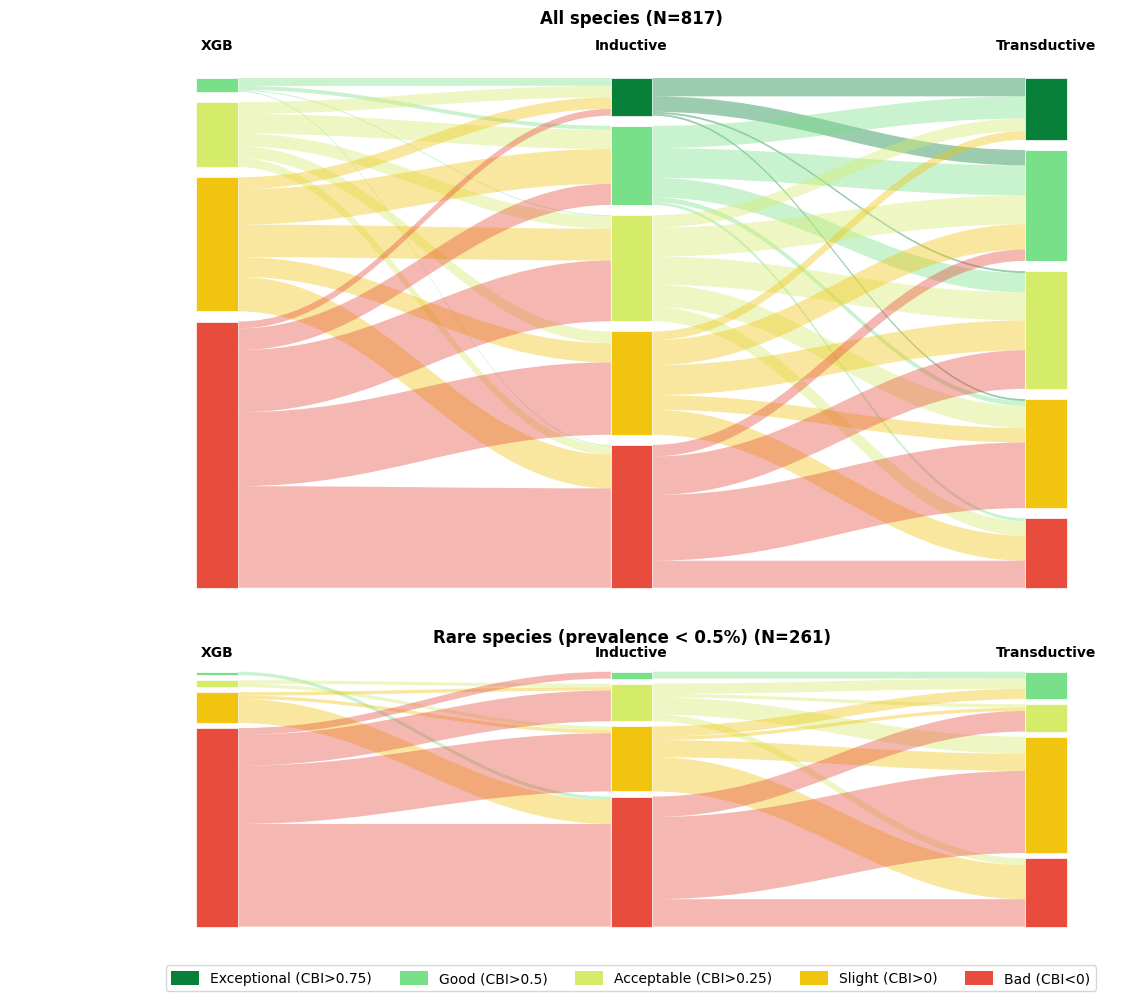

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.path import Path
import numpy as np
import pandas as pd

# category_colors = {
#     'Exceptional (AUC>0.98)': '#09803a',
#     'Good (AUC>0.95)':        '#78e089',
#     'Acceptable (AUC>0.9)':  '#d5ec6a',
#     'Slight (AUC>0.8)':      '#f1c40f',
#     'Bad (AUC<0.8)':         '#e74c3c',
# }

category_colors = {
    'Exceptional (CBI>0.75)': '#09803a',
    'Good (CBI>0.5)':        '#78e089',
    'Acceptable (CBI>0.25)':  '#d5ec6a',
    'Slight (CBI>0)':      '#f1c40f',
    'Bad (CBI<0)':         '#e74c3c',
}

models = ['XGB', 'Inductive', 'Transductive']

def draw_sankey(ax, df, title):
    #df = df[~((df['XGB'] == 'Bad') & (df['Inductive'] == 'Bad') & (df['Transductive'] == 'Bad'))]
    df = df[~((df['XGB'] == df['Inductive']) & (df['Transductive'] == df['Inductive']))]

    total = len(df)
    pad = 0.02          # gap between nodes as fraction of total
    col_width = 0.05    # visual width of each node bar
    col_x = [0.0, 0.5, 1.0]  # x positions of the 3 columns

    # Compute node heights and y positions for a given column
    def get_node_layout(model):
        counts = [(df[model] == cat).sum() for cat in categories]
        n_present = sum(1 for c in counts if c > 0)
        total_pad = pad * (n_present - 1)
        available = 1.0 - total_pad
        heights, y_starts = [], []
        y = 1.0
        for i, cat in enumerate(categories):
            h = (counts[i] / total) * available if counts[i] > 0 else 0
            if counts[i] > 0:
                y -= h
                heights.append(h)
                y_starts.append(y)
                y -= pad
            else:
                heights.append(0)
                y_starts.append(None)
        return counts, heights, y_starts

    layouts = {model: get_node_layout(model) for model in models}

    # Draw node bars
    for col_i, model in enumerate(models):
        counts, heights, y_starts = layouts[model]
        for j, cat in enumerate(categories):
            if y_starts[j] is None:
                continue
            rect = mpatches.FancyBboxPatch(
                (col_x[col_i] - col_width / 2, y_starts[j]),
                col_width, heights[j],
                boxstyle="square,pad=0",
                facecolor=category_colors[cat],
                edgecolor='white', linewidth=0.5,
                zorder=3
            )
            ax.add_patch(rect)
            # Label


    # Draw flows between columns
    def draw_flow(ax, x_left, x_right, y_left_top, y_left_bot, y_right_top, y_right_bot, color):
        verts = [
            (x_left,  y_left_top),
            (x_left + (x_right - x_left) * 0.4, y_left_top),
            (x_right - (x_right - x_left) * 0.4, y_right_top),
            (x_right, y_right_top),
            (x_right, y_right_bot),
            (x_right - (x_right - x_left) * 0.4, y_right_bot),
            (x_left + (x_right - x_left) * 0.4, y_left_bot),
            (x_left,  y_left_bot),
            (x_left,  y_left_top),
        ]
        codes = [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4,
                 Path.LINETO, Path.CURVE4, Path.CURVE4, Path.CURVE4, Path.CLOSEPOLY]
        path = Path(verts, codes)
        patch = mpatches.PathPatch(path, facecolor=color, edgecolor='none', alpha=0.4, zorder=2)
        ax.add_patch(patch)

    for col_i in range(len(models) - 1):
        left_model  = models[col_i]
        right_model = models[col_i + 1]
        x_left  = col_x[col_i]  + col_width / 2
        x_right = col_x[col_i + 1] - col_width / 2

        l_counts, l_heights, l_y_starts = layouts[left_model]
        r_counts, r_heights, r_y_starts = layouts[right_model]

        # Track current fill position within each node
        left_fill  = [l_y_starts[j] + l_heights[j] if l_y_starts[j] is not None else None for j in range(len(categories))]
        right_fill = [r_y_starts[j] + r_heights[j] if r_y_starts[j] is not None else None for j in range(len(categories))]

        for li, left_cat in enumerate(categories):
            if l_y_starts[li] is None:
                continue
            for ri, right_cat in enumerate(categories):
                if r_y_starts[ri] is None:
                    continue
                count = ((df[left_model] == left_cat) & (df[right_model] == right_cat)).sum()
                if count == 0:
                    continue

                flow_h_left  = (count / total) * (1.0 - pad * (sum(1 for c in l_counts if c > 0) - 1))
                flow_h_right = (count / total) * (1.0 - pad * (sum(1 for c in r_counts if c > 0) - 1))

                y_left_top  = left_fill[li]
                y_left_bot  = left_fill[li] - flow_h_left
                y_right_top = right_fill[ri]
                y_right_bot = right_fill[ri] - flow_h_right

                left_fill[li]  -= flow_h_left
                right_fill[ri] -= flow_h_right

                draw_flow(ax, x_left, x_right,
                          y_left_top, y_left_bot,
                          y_right_top, y_right_bot,
                          color=category_colors[left_cat])

    ax.set_xlim(-0.25, 1.1)
    ax.set_ylim(-0.05, 1.1)
    ax.axis('off')
    ax.text(0.5, 1.1, title, ha='center', va='bottom', fontsize=12, 
        fontweight='bold', transform=ax.transData)
    
    # Column headers
    for col_i, model in enumerate(models):
        ax.text(col_x[col_i], 1.05, model, ha='center', va='bottom', fontsize=10, fontweight='bold')

fig, axes = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [2, 1]})
draw_sankey(axes[0], qualscores, f"All species (N={qualscores.shape[0]})")
#draw_sankey(axes[1], qualscores[qualscores['uicnL_threatened'] == 1], "Threatened species")
draw_sankey(axes[1], qualscores[qualscores['prevalence'] < 0.005], f"Rare species (prevalence < 0.5%) (N={qualscores[qualscores['prevalence'] < 0.005].shape[0]})")

handles = [mpatches.Patch(facecolor=category_colors[cat], edgecolor='none', label=cat) for cat in categories]

legend = plt.legend(
    handles=handles,
    loc='lower center',
    fontsize=10,
    framealpha=0.8,
    handleheight=1.2,
    ncol=5,
    bbox_to_anchor=(0.055, -0.2, 1., .102),
)

plt.tight_layout()
plt.savefig('sankey.png', dpi=150, bbox_inches='tight')
plt.show()

#### Site F1

In [53]:
sites = pd.read_csv(inputs_path / 'site_metadata.csv', index_col='site_code').dropna()

xgb_f1_site = pd.read_csv(output_path.parent / 'xgb' / 'pa' / 'f1_by_site.csv', index_col = 0)
ind_f1_site = pd.read_csv(output_path / ind_cp_pa / 'f1_by_site.csv', index_col = 0)
td_f1_site = pd.read_csv(output_path / td_cp_pa / 'f1_by_site.csv', index_col = 0)

sites['XGB'] = xgb_f1_site['mean']
sites['IND'] = ind_f1_site['mean']
sites['TD'] = td_f1_site['mean']

sites['delta'] = (sites['TD'] - sites['XGB'])

In [54]:
import plotly.express as px

fig = px.scatter_map(sites, lat='latitude',lon='longitude', color='delta', height = 700, width = 800,
                     center={'lat':-28, 'lon':133}, zoom=3, opacity=0.5,
                     color_continuous_midpoint=0,
                     color_continuous_scale=px.colors.sequential.RdBu, map_style='dark')

fig.update_traces(marker=dict(size=20))
fig.show()

In [56]:
print((sites['delta'] / (sites['XGB']+1e-6)).describe())
print((sites['TD'] - sites['IND']).describe())

count    412.000000
mean       0.242027
std        0.373990
min       -0.960104
25%        0.060404
50%        0.214892
75%        0.415689
max        3.805978
dtype: float64
count    412.000000
mean       0.022384
std        0.073349
min       -0.208802
25%       -0.018816
50%        0.020586
75%        0.063430
max        0.271406
dtype: float64


In [ ]:
import seaborn as sns
from matplotlib import pyplot as plt

x, y = sites['XGB'].values, sites['TD'].values

# Draw a combo histogram and scatterplot with density contours
f, ax = plt.subplots(figsize=(9, 9))
sns.scatterplot(x=x, y=y, s=5, color=".15")
sns.histplot(x=x, y=y, bins=40, pthresh=.1, cmap="mako")
sns.kdeplot(x=x, y=y, levels=5, color="w", linewidths=1)
sns.lineplot(x=[min(x), max(x)], y=[min(x), max(x)],color='red')
ax.set(xlabel='XGB F1', ylabel='TD F1')

In [ ]:
import seaborn as sns
from matplotlib import pyplot as plt

sites['delta'] = sites['TD'] - sites['IND']
sites['distance_cat'] = pd.cut(sites['distance_km'], bins=[0, 50, 100, 150, 200, 300, np.inf], labels=['0-50', '50-100', '100-150', '150-200', '200-300', '300+'])

fig = px.violin(sites, x="distance_cat", y="delta", points = 'all', color = "distance_cat",
                color_discrete_sequence= px.colors.qualitative.Pastel, box = True,
                category_orders={'distance_cat': ['0-50', '50-100', '100-150', '150-200', '200-300', '300+']})


fig.update_layout(
    template='simple_white',
    width = 800, height=800,
    yaxis_title='F1 delta',
    xaxis_title='Distance to closest training point (km)',
    font=dict(size=20),
    showlegend=False)
    

fig.add_shape(type="line",
    xref="paper",
    x0=0, y0=0,
    x1=1, y1=0,
    line=dict(
        color="black",
        width=1,
    ))

fig.show()

## Reg

In [4]:
xgb_mean, xgb_ci = load_bootstrap_metrics(output_path.parent / 'xgb', 'reg')
ind_mean, ind_ci = load_bootstrap_metrics(output_path, ind_cp_reg)
td_mean, td_ci = load_bootstrap_metrics(output_path, td_cp_reg)

In [5]:
scores = [xgb_mean, ind_mean, td_mean]
errors = [xgb_ci, ind_ci, td_ci]
names = ['XGBoost', 'Deep-SDM', 'Transductive']

In [7]:
fig = go.Figure()

colors = px.colors.qualitative.Pastel

# CI band — upper and lower as a filled trace

for i, n in enumerate(names):

    if errors[i] is not None:

        fig.add_trace(go.Scatter(
            x=np.concatenate([np.arange(400), np.arange(400)[::-1]]),
            y=np.concatenate([scores[i] + errors[i], (scores[i] - errors[i])[::-1]]),
            fill='toself',
            fillcolor=colors[i % len(colors)].replace('rgb(', 'rgba(').replace(')', ', 0.4)'),
            line=dict(color='rgba(255,255,255,0)'),  # no border line
            name='95% CI',
        ))

    # Mean curve (on top)
    fig.add_trace(go.Scatter(
        x=np.arange(400), y=np.array(scores[i]),
        mode='lines',
        line=dict(color=colors[i % len(colors)], width=3),
        name=n,
    ))

fig.update_layout(
    template='simple_white',
    width=1200, height=800,
    title='', #'Presence-absence classification',
    xaxis_title='Species rank',
    yaxis_title='Pearson R',
    font=dict(size=20),
    legend_title_text='',
    legend=dict(yanchor="top",
                y=0.99,
                xanchor="right",
                x=0.99)
)

fig.show()

In [ ]:
scores['delta'] = (scores['Transductive'] - scores['XGBoost']) / (scores['XGBoost']+1e-6)
scores['delta'].describe()

## Traits based

In [12]:
species_prev = (groundtruth > 0).sum(axis=0) / groundtruth.shape[0]

#### Load scores to compare

In [65]:
# P-A
metric = 'AUC'

xgb_mean, xgb_ci = load_bootstrap_metrics(output_path.parent / 'xgb', 'pa', pa_metric=metric, reindex = False)
ind_mean, ind_ci = load_bootstrap_metrics(output_path, ind_cp_pa, pa_metric=metric, reindex = False)
td_mean, td_ci = load_bootstrap_metrics(output_path, td_cp_pa, pa_metric=metric, reindex = False)

loaded_scores = pd.concat([xgb_mean, td_mean], axis = 1)
names = ['XGB', 'Transductive']
loaded_scores.columns = names

In [29]:
## Marbec-gpu only
# import plotly.io as pio
# pio.renderers.default = 'notebook'

In [66]:
# Calculate progress 2-way

scores = pd.concat([loaded_scores, get_traits(loaded_scores.index, traits_path = inputs_path)], axis=1)
scores['prevalence'] = species_prev[scores.index]
scores['prevalence_cat'] = pd.cut(scores['prevalence'], bins=[0, 0.005, 0.01, 0.02,0.05,0.1,1], labels=['0-0.5%', '0.5-1%', '1-2%', '2-5%', '5-10%', '10%+'])

scores['progress_perc'] = (scores[names[1]] - scores[names[0]]) / (scores[names[0]] + 1e-6)
scores['progress'] = (scores[names[1]] - scores[names[0]]) 
scores['max'] = scores[names].max(axis=1)
scores['XGB'] = scores['XGB'].fillna(0)

relevant_scores_auc = scores.copy().sort_values(by='progress', ascending=False)

In [67]:
print(relevant_scores_auc['progress'].describe()['50%'])

print(relevant_scores_auc.groupby('uicnL_status')['progress'].describe()['50%'])
print(relevant_scores_auc.groupby('prevalence_cat')['progress'].describe()['50%'])


0.10720238587735181
uicnL_status
No Status         0.121281
Non Threatened    0.102001
Threatened        0.163001
Name: 50%, dtype: float64
prevalence_cat
0-0.5%    0.176720
0.5-1%    0.150232
1-2%      0.097216
2-5%      0.058460
5-10%     0.029624
10%+      0.022175
Name: 50%, dtype: float64


/tmp/ipykernel_218898/1525082713.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(relevant_scores_auc.groupby('prevalence_cat')['progress'].describe()['50%'])


#### Plot performance increase vs traits

In [36]:
t = 'prevalence_cat' 

fig = px.violin(relevant_scores_auc, x=t, y="progress", points = 'all', color = t,
                color_discrete_sequence= px.colors.qualitative.Pastel, box = True,
                category_orders={t: ['0-0.5%', '0.5-1%', '1-2%', '2-5%', '5-10%', '10%+']})


fig.update_layout(
    template='simple_white',
    width = 800, height=800,
    yaxis_title=f"AUC-ROC gain",
    xaxis_title="Vulnerability status",
    font=dict(size=20),
    showlegend=False)
    

fig.add_shape(type="line",
    xref="paper",
    x0=0, y0=0,
    x1=1, y1=0,
    line=dict(
        color="black",
        width=1,
    ))

fig.show()

In [ ]:
best = pd.merge(relevant_scores_boyce.iloc[:100][['XGB', 'Transductive']], relevant_scores_auc.iloc[:100], left_index=True, right_index=True, suffixes=('_boyce', '_auc'))
print(best)

### 3-way comparison

In [68]:
metric = 'Boyce'

xgb_mean, xgb_ci = load_bootstrap_metrics(output_path.parent / 'xgb', 'pa', pa_metric=metric, reindex = False)
ind_mean, ind_ci = load_bootstrap_metrics(output_path, ind_cp_pa, pa_metric=metric, reindex = False)
td_mean, td_ci = load_bootstrap_metrics(output_path, td_cp_pa, pa_metric=metric, reindex = False)

loaded_scores = pd.concat([xgb_mean, ind_mean, td_mean], axis = 1)
names = ['XGB', 'Inductive', 'Transductive']
loaded_scores.columns = names

loaded_scores.fillna(0, inplace=True)


In [69]:
# Calculate progress 2-way

scores = pd.concat([loaded_scores, get_traits(loaded_scores.index, traits_path = inputs_path)], axis=1)

scores['prevalence'] = species_prev[scores.index]
scores['prevalence_cat'] = pd.cut(scores['prevalence'], bins=[0, 0.005, 0.01, 0.02,0.05,0.1,1], labels=['0-0.5%', '0.5-1%', '1-2%', '2-5%', '5-10%', '10%+'])

scores['progress1'] = (scores[names[1]] - scores[names[0]]) 
scores['progress1_perc'] = (scores[names[1]] - scores[names[0]]) / (scores[names[0]] + 1e-6)

scores['progress2'] = (scores[names[2]] - scores[names[1]]) 
scores['progress2_perc'] = (scores[names[2]] - scores[names[1]]) / (scores[names[1]] + 1e-6)

In [70]:
print(scores['progress1'].describe()['50%'])
print(scores['progress2'].describe()['50%'])

0.09203216261809327
0.06167690634305045


In [87]:
print(scores.groupby('prevalence_cat')['progress1'].describe())
print(scores.groupby('prevalence_cat')['progress2'].describe())

                count      mean       std       min       25%       50%  \
prevalence_cat                                                            
0-0.5%          261.0  0.019145  0.298771 -1.033993 -0.165331 -0.002475   
0.5-1%          150.0  0.060360  0.342025 -0.680645 -0.184932  0.035617   
1-2%            161.0  0.212616  0.384485 -0.858874 -0.039620  0.223186   
2-5%            156.0  0.226021  0.356769 -0.821719 -0.057354  0.232078   
5-10%            55.0  0.201542  0.307323 -0.569473  0.001354  0.173905   
10%+             34.0  0.283072  0.306877 -0.293281  0.100996  0.254275   

                     75%       max  
prevalence_cat                      
0-0.5%          0.166703  1.169946  
0.5-1%          0.276747  1.013579  
1-2%            0.448420  1.179045  
2-5%            0.445731  0.985133  
5-10%           0.414202  1.087934  
10%+            0.454211  1.246129  
                count      mean       std       min       25%       50%  \
prevalence_cat              

/tmp/ipykernel_218898/2481436462.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(scores.groupby('prevalence_cat')['progress1'].describe())
/tmp/ipykernel_218898/2481436462.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(scores.groupby('prevalence_cat')['progress2'].describe())


## Eco indicators

In [4]:
xgb_mean, xgb_ci = load_bootstrap_metrics('/data/data/malpolon/xgb/', 'eco')
ind_mean, ind_ci = load_bootstrap_metrics(output_path, ind_cp_eco)
td_mean, td_ci = load_bootstrap_metrics(output_path, td_cp_eco)

tdstacked_r2 = pd.read_csv(output_path / td_cp_pa / 'eco_indic_corr.csv', index_col=0)

In [5]:
td_mean

log_sr         0.791290
log_uicn_sr    0.671235
log_bm         0.561853
dtype: float64

In [ ]:
scores = pd.concat([xgb_mean, ind_mean, td_mean, tdstacked_r2["mean"]], axis = 1)
errors = [xgb_ci, ind_ci, td_ci, None]
names = ['XGBoost', 'Deep-SDM', 'Transductive (direct)', 'Transductive (stacked)']
scores.columns = names

In [ ]:
fig = go.Figure()

colors = px.colors.qualitative.Pastel

for i, n in enumerate(names[:-1]):
    fig.add_trace(go.Bar(
        name=n,
        x=scores.index, y=scores.iloc[:,i],
        error_y=dict(type='data', array=errors[i]),
        marker_color=colors[i % len(colors)],
    ))

fig.add_trace(go.Bar(
    name=names[-1],
    x=tdstacked_r2.index, y=scores.iloc[:,-1],
    error_y=dict(type='data',
                 symmetric=False,
                 array=tdstacked_r2['max'] - scores.iloc[:,-1],
                 arrayminus=scores.iloc[:,-1] -tdstacked_r2['min']),
    marker_color=colors[len(names) -1 % len(colors)],
    ))

fig.update_layout(barmode='group',
                  width = 800, height=800,
                  template = 'simple_white',
                  title='',
                  xaxis_title='',
                  yaxis_title='Pearson R',
                  font=dict(size=20),
                  legend_title_text='',
                  legend=dict(yanchor="top",
                              y=0.99,
                              xanchor="center",
                              x=0.5),
)

fig.show()


# fig = px.bar(data, x=data['species'], y='pearsonr', color='model', template = 'simple_white', barmode='group',
#            width = 800, height=800,
#            )


## Any 2

In [42]:
xgb_mean, xgb_ci = load_bootstrap_metrics(output_path.parent / 'xgb', 'pa', reindex=False)
ind_mean, ind_ci = load_bootstrap_metrics(output_path, ind_cp_pa, reindex=False)
td_mean, td_ci = load_bootstrap_metrics(output_path, td_cp_pa, reindex=False)

scores = [xgb_mean, ind_mean, td_mean]
errors = [xgb_ci, ind_ci, td_ci]
names = ['XGBoost', 'Inductive', 'Transductive']

In [45]:
to_compare = ['XGBoost', 'Transductive']
scoresdf = pd.concat([scores[names.index(c)].rename(c) for c in to_compare], names=to_compare, axis=1)

# Calculate progress

scoresdf['progress_perc'] = (scoresdf[to_compare[1]] - scoresdf[to_compare[0]]) / (scoresdf[to_compare[0]] + 1e-6)
scoresdf['progress'] = (scoresdf[to_compare[1]] - scoresdf[to_compare[0]]) 
scoresdf['max'] = scoresdf[to_compare].max(axis=1)
scoresdf['prevalence'] = np.log(1+(groundtruth > 0).sum(axis=0).loc[scoresdf.index])

relevant_scores = scoresdf.loc[scoresdf['max'] > 0.2].copy()

relevant_scores.sort_values(by=to_compare[0], ascending=False, inplace=True)
relevant_scores['x'] = np.arange(len(relevant_scores))

#### 1v1 BlandAltman

In [ ]:
import pyCompare

pyCompare.blandAltman(scores[names[2]].values,scores[names[0]].values)

#### 1v1 Scatter plot

[Text(0.5, 0, 'XGBoost F1'), Text(0, 0.5, 'Transductive F1')]

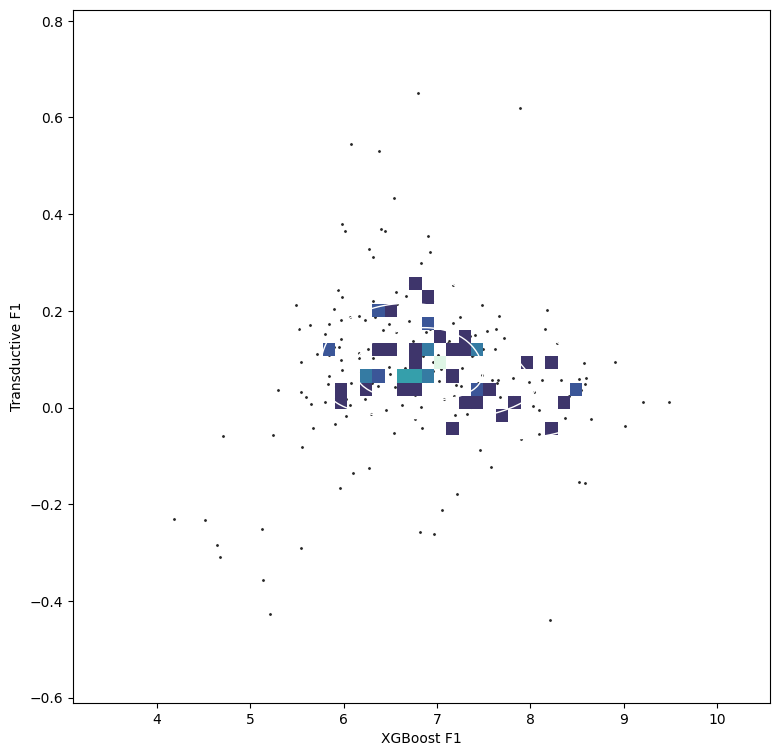

In [47]:
import seaborn as sns
from matplotlib import pyplot as plt

x, y = relevant_scores['prevalence'].values, relevant_scores['progress'].values

# Draw a combo histogram and scatterplot with density contours
f, ax = plt.subplots(figsize=(9, 9))
sns.scatterplot(x=x, y=y, s=5, color=".15")
sns.histplot(x=x, y=y, bins=40, pthresh=.1, cmap="mako")
sns.kdeplot(x=x, y=y, levels=5, color="w", linewidths=1)
#sns.lineplot(x=[min(x), max(x)], y=[min(x), max(x)],color='red')
ax.set(xlabel=names[0] + ' F1', ylabel=names[2] + ' F1')

#### 1v1 arrow scatter

In [38]:
# Example data
x = relevant_scores['x']
y1 = relevant_scores[to_compare[0]]
y2 = relevant_scores[to_compare[1]]
hover_text = relevant_scores.index.to_list()

# Create the figure
fig = go.Figure()

# Add the two series as scatter plots
fig.add_trace(go.Scatter(
    x=x, y=y1,
    mode='markers',
    marker=dict(color=px.colors.qualitative.Pastel[0],
                size=relevant_scores['prevalence']),
    name=to_compare[0],
    hovertext=hover_text,
    hoverinfo='text'
))

fig.add_trace(go.Scatter(
    x=x, y=y2,
    mode='markers',
    marker=dict(color=px.colors.qualitative.Pastel[3],
                size=relevant_scores['prevalence']),
    name=to_compare[1],
    hovertext=hover_text,
    hoverinfo='text'
))

# Add arrows for the differences
for i in range(len(x)):
    fig.add_annotation(
        ax=x[i], ay=y1[i],
        axref='x', ayref='y',
        x=x[i], y=y2[i],
        xref='x', yref='y',
        showarrow=True,
        arrowhead=1,
        arrowsize=1.5,
        arrowcolor=px.colors.qualitative.Pastel1[1],
        arrowwidth=1.5,
    )


fig.update_layout(
    template='simple_white',
    width = 1200, height=800,
    xaxis_title='Species rank',
    yaxis_title='F1 score',
    font=dict(size=20),
    legend=dict(yanchor="top",
                y=0.99,
                xanchor="right",
                x=0.99)
)


/tmp/ipykernel_22539/1039493605.py:34: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax=x[i], ay=y1[i],
/tmp/ipykernel_22539/1039493605.py:36: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x=x[i], y=y2[i],
